In [2]:
# Reproduction of Figures 4-12 from Neely & Kim (1986), "A model for active
# elements in cochlear biomechanics", JASA 79(5), 1472-1480.
#
# Uses the CSV-driven parameter tables (params_loader.py): CAT_PARAMS
# reproduces Neely & Kim's own cat model exactly (Table I); HUMAN_PARAMS
# is Ku (2010) plus our own derivations, used later for a human contrast
# where noted. Figures 4-8 are internal to the model (no external
# comparison data -- they are the model exploring its own behavior at
# different frequencies/gamma). Figues 9, 11, 12 add real measured data.
import numpy as np
import matplotlib.pyplot as plt
import dataclasses

from cochleasim.models.cochlear_model import solve_pressure, displacement_from_pressure, P_REF_DYN_CM2
from cochleasim.models.params_loader import CAT_PARAMS, HUMAN_PARAMS

N = 1000

In [3]:
# ---------------------------------------------------------------------
# Figures 4-6: Pd(x), xi_b(x), xi_c(x) at 4 fixed frequencies
# (0.4, 1.6, 6.4, 25.6 kHz), cat table, gamma=1, stimulus at 0 dB SPL
# (P_e = P_REF_DYN_CM2). Neely & Kim plot magnitude in dB (Pd re P_e;
# xi_b, xi_c re 1 nm) and phase in cycles, vs. fractional distance x/L.
# ---------------------------------------------------------------------
test_freqs_khz = [0.4, 1.6, 6.4, 25.6]
params = dataclasses.replace(CAT_PARAMS, gamma=0.0)

results_468 = {}
for f_khz in test_freqs_khz:
    omega = 2 * np.pi * f_khz * 1000
    x, Pd = solve_pressure(omega, P_REF_DYN_CM2, params, N=N)
    xi_b, xi_c = displacement_from_pressure(x, Pd, omega, params)
    results_468[f_khz] = dict(x=x, Pd=Pd, xi_b=xi_b, xi_c=xi_c)

0.4 kHz:
  Pico = 37.20 dB
  x/L = 0.000
1.6 kHz:
  Pico = 37.24 dB
  x/L = 0.000
6.4 kHz:
  Pico = 37.24 dB
  x/L = 0.000
25.6 kHz:
  Pico = 37.21 dB
  x/L = 0.000


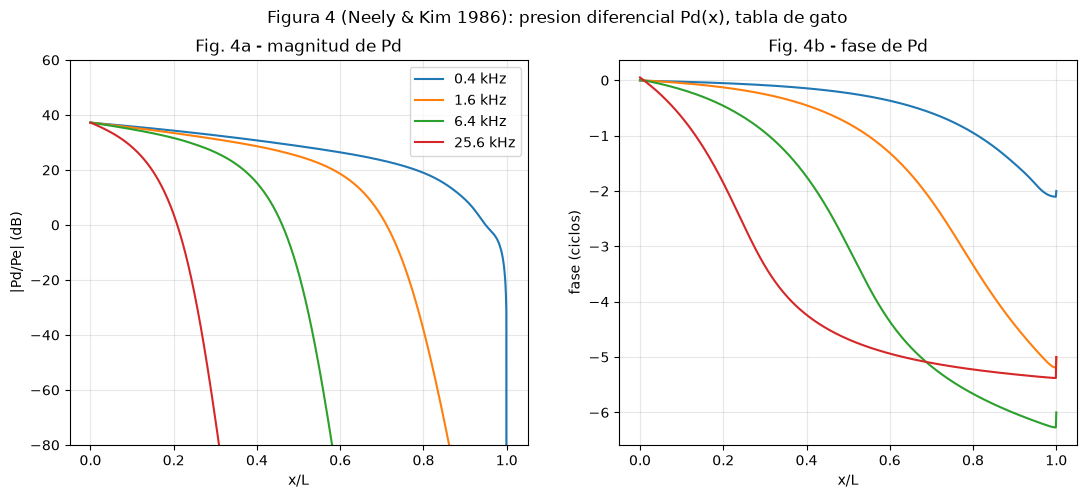

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for f_khz in test_freqs_khz:
    r = results_468[f_khz]
    mag_db = 20 * np.log10(np.abs(r["Pd"]) / P_REF_DYN_CM2 + 1e-30)
    phase_cyc = np.unwrap(np.angle(r["Pd"])) / (2 * np.pi)
    axes[0].plot(r["x"] / params.L, mag_db, label=f"{f_khz} kHz")
    axes[1].plot(r["x"] / params.L, phase_cyc, label=f"{f_khz} kHz")
axes[0].set_xlabel("x/L"); axes[0].set_ylabel("|Pd/Pe| (dB)"); axes[0].set_title("Fig. 4a - magnitud de Pd")
axes[1].set_xlabel("x/L"); axes[1].set_ylabel("fase (ciclos)"); axes[1].set_title("Fig. 4b - fase de Pd")
axes[0].legend(); axes[0].grid(alpha=0.3); axes[1].grid(alpha=0.3)
axes[0].set_ylim(-80, 60)
fig.suptitle("Figura 4 (Neely & Kim 1986): presion diferencial Pd(x), tabla de gato")
f_khz = test_freqs_khz[0]  # por ejemplo, la primera frecuencia
for f_khz, r in results_468.items():
    mag_db = 20 * np.log10(np.abs(r["Pd"]) / P_REF_DYN_CM2 + 1e-30)
    idx = np.argmax(mag_db)
    print(f"{f_khz} kHz:")
    print(f"  Pico = {mag_db[idx]:.2f} dB")
    print(f"  x/L = {r['x'][idx]/params.L:.3f}")

Text(0.5, 0.98, 'Figura 5 (Neely & Kim 1986): desplazamiento de la BM xi_b(x), tabla de gato')

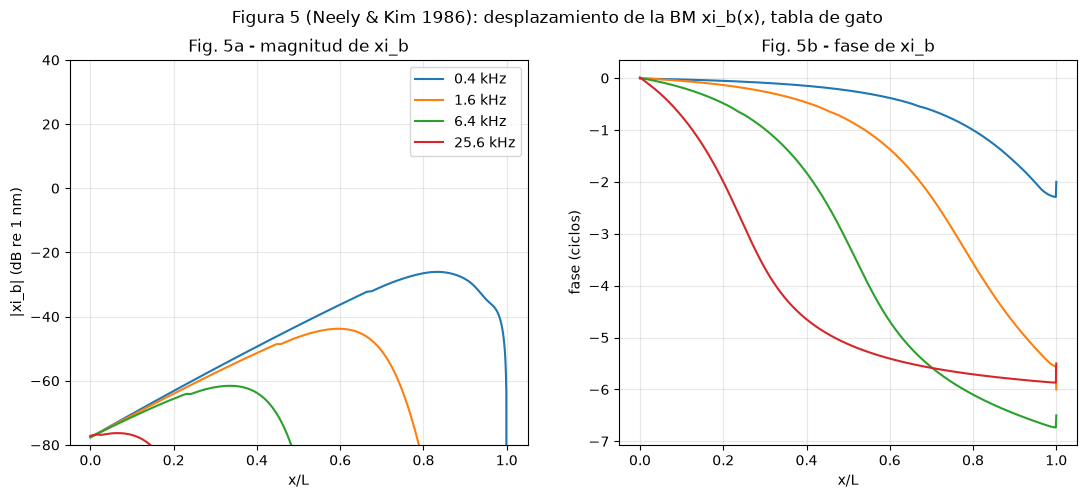

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for f_khz in test_freqs_khz:
    r = results_468[f_khz]
    mag_db_nm = 20 * np.log10(np.abs(r["xi_b"]) * 1e7 + 1e-30)
    phase_cyc = np.unwrap(np.angle(r["xi_b"])) / (2 * np.pi)
    axes[0].plot(r["x"] / params.L, mag_db_nm, label=f"{f_khz} kHz")
    axes[1].plot(r["x"] / params.L, phase_cyc, label=f"{f_khz} kHz")
axes[0].set_xlabel("x/L"); axes[0].set_ylabel("|xi_b| (dB re 1 nm)"); axes[0].set_title("Fig. 5a - magnitud de xi_b")
axes[1].set_xlabel("x/L"); axes[1].set_ylabel("fase (ciclos)"); axes[1].set_title("Fig. 5b - fase de xi_b")
axes[0].legend(); axes[0].grid(alpha=0.3); axes[1].grid(alpha=0.3)
axes[0].set_ylim(-80, 40)
fig.suptitle("Figura 5 (Neely & Kim 1986): desplazamiento de la BM xi_b(x), tabla de gato")

Figuras 4-6: recrean la Fig 1 de la memoria - Pd, xi_b, xi_c a lo largo de x, para 4 frecuencias fijas.
El pico de cada curva se desplaza hacia la base (x/L menor) conforme sube la frecuencia -- tonotopia.


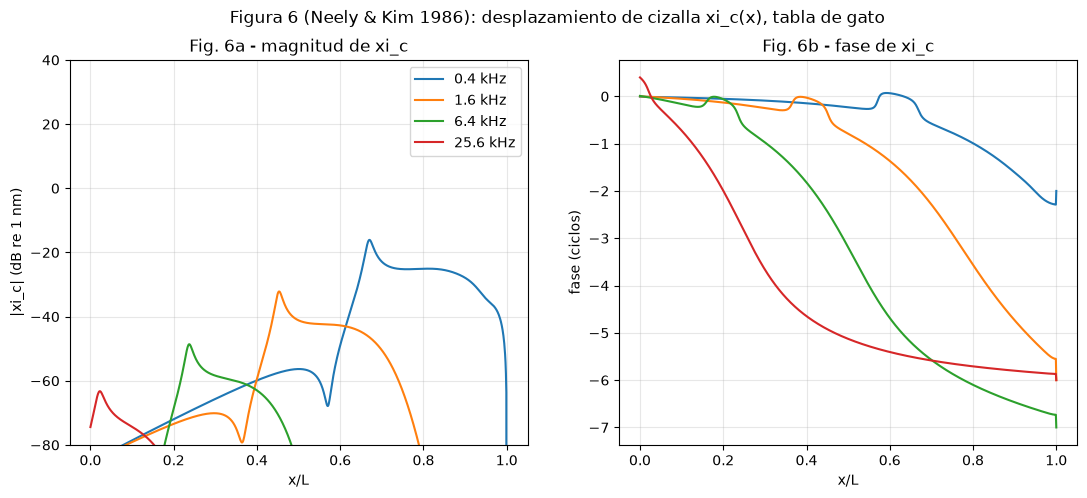

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for f_khz in test_freqs_khz:
    r = results_468[f_khz]
    mag_db_nm = 20 * np.log10(np.abs(r["xi_c"]) * 1e7 + 1e-30)
    phase_cyc = np.unwrap(np.angle(r["xi_c"])) / (2 * np.pi)
    axes[0].plot(r["x"] / params.L, mag_db_nm, label=f"{f_khz} kHz")
    axes[1].plot(r["x"] / params.L, phase_cyc, label=f"{f_khz} kHz")
axes[0].set_xlabel("x/L"); axes[0].set_ylabel("|xi_c| (dB re 1 nm)"); axes[0].set_title("Fig. 6a - magnitud de xi_c")
axes[1].set_xlabel("x/L"); axes[1].set_ylabel("fase (ciclos)"); axes[1].set_title("Fig. 6b - fase de xi_c")
axes[0].legend(); axes[0].grid(alpha=0.3); axes[1].grid(alpha=0.3)
axes[0].set_ylim(-80, 40)
fig.suptitle("Figura 6 (Neely & Kim 1986): desplazamiento de cizalla xi_c(x), tabla de gato")
print("Figuras 4-6: recrean la Fig 1 de la memoria - Pd, xi_b, xi_c a lo largo de x, para 4 frecuencias fijas.")
print("El pico de cada curva se desplaza hacia la base (x/L menor) conforme sube la frecuencia -- tonotopia.")

gamma=1.12 deberia mostrar un pico mucho mas afilado/alto -- cerca del umbral de inestabilidad reportado por el paper.


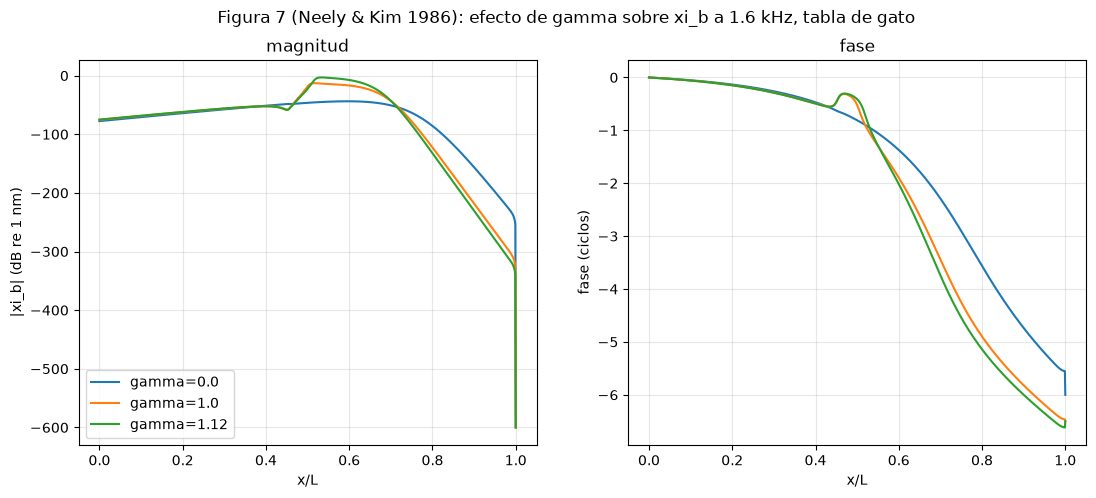

In [7]:
# ---------------------------------------------------------------------
# Figure 7: effect of gamma on xi_b(x) at a single frequency (1.6 kHz).
# Neely & Kim show gamma=0 (passive), gamma=1 (normal), gamma=1.12
# (unstable -- their reported instability threshold for the cat table).
# ---------------------------------------------------------------------
f7_khz = 1.6
omega7 = 2 * np.pi * f7_khz * 1000
gammas_fig7 = [0.0, 1.0, 1.12]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for g in gammas_fig7:
    p = dataclasses.replace(CAT_PARAMS, gamma=g)
    x, Pd = solve_pressure(omega7, P_REF_DYN_CM2, p, N=N)
    xi_b, _ = displacement_from_pressure(x, Pd, omega7, p)
    mag_db_nm = 20 * np.log10(np.abs(xi_b) * 1e7 + 1e-30)
    phase_cyc = np.unwrap(np.angle(xi_b)) / (2 * np.pi)
    axes[0].plot(x / p.L, mag_db_nm, label=f"gamma={g}")
    axes[1].plot(x / p.L, phase_cyc, label=f"gamma={g}")
axes[0].set_xlabel("x/L"); axes[0].set_ylabel("|xi_b| (dB re 1 nm)"); axes[0].set_title("magnitud")
axes[1].set_xlabel("x/L"); axes[1].set_ylabel("fase (ciclos)"); axes[1].set_title("fase")
axes[0].legend(); axes[0].grid(alpha=0.3); axes[1].grid(alpha=0.3)
fig.suptitle(f"Figura 7 (Neely & Kim 1986): efecto de gamma sobre xi_b a {f7_khz} kHz, tabla de gato")
print("gamma=1.12 deberia mostrar un pico mucho mas afilado/alto -- cerca del umbral de inestabilidad reportado por el paper.")

Ganancia pico activo/pasivo (referencia del paper: ~24dB @ 0.4kHz, ~63dB @ 6.4kHz):
  0.4 kHz: 25.16 dB
  6.4 kHz: 41.62 dB


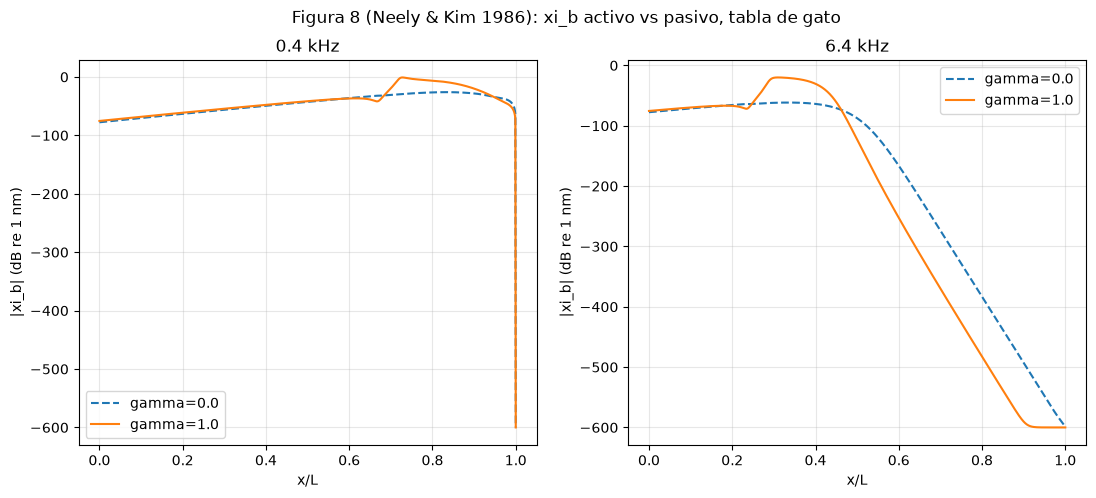

In [8]:
# ---------------------------------------------------------------------
# Figure 8: xi_b(x) for gamma=0 (passive) vs gamma=1 (active), at the
# two frequencies used throughout the paper's gain comparisons
# (0.4 and 6.4 kHz). This is the "24 dB / 63 dB" gain figure we
# validated numerically earlier in this project.
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
gains_fig8 = {}
for ax, f_khz in zip(axes, [0.4, 6.4]):
    omega = 2 * np.pi * f_khz * 1000
    for g, style in [(0.0, "--"), (1.0, "-")]:
        p = dataclasses.replace(CAT_PARAMS, gamma=g)
        x, Pd = solve_pressure(omega, P_REF_DYN_CM2, p, N=N)
        xi_b, _ = displacement_from_pressure(x, Pd, omega, p)
        mag_db_nm = 20 * np.log10(np.abs(xi_b) * 1e7 + 1e-30)
        ax.plot(x / p.L, mag_db_nm, style, label=f"gamma={g}")
        if g == 1.0:
            peak_active = np.max(np.abs(xi_b))
        else:
            peak_passive = np.max(np.abs(xi_b))
    gains_fig8[f_khz] = 20 * np.log10(peak_active / peak_passive)
    ax.set_xlabel("x/L"); ax.set_ylabel("|xi_b| (dB re 1 nm)"); ax.set_title(f"{f_khz} kHz")
    ax.legend(); ax.grid(alpha=0.3)
fig.suptitle("Figura 8 (Neely & Kim 1986): xi_b activo vs pasivo, tabla de gato")

print("Ganancia pico activo/pasivo (referencia del paper: ~24dB @ 0.4kHz, ~63dB @ 6.4kHz):")
for f_khz, g in gains_fig8.items():
    print(f"  {f_khz} kHz: {g:.2f} dB")